# Rainfall Prediction – Random Forest Classifier

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc,
                             accuracy_score, precision_score, recall_score, f1_score)
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
PALETTE = ['#4C72B0','#DD8452']

## 2. Data Collection & Initial Exploration

In [3]:
data = pd.read_csv('Rainfall.csv')
data.columns = data.columns.str.strip()   # remove whitespace from col names
print('Shape:', data.shape)
data.head()

Shape: (366, 12)


,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            366 non-null    int64  
 1   pressure       366 non-null    float64
 2   maxtemp        366 non-null    float64
 3   temparature    366 non-null    float64
 4   mintemp        366 non-null    float64
 5   dewpoint       366 non-null    float64
 6   humidity       366 non-null    int64  
 7   cloud          366 non-null    int64  
 8   rainfall       366 non-null    object 
 9   sunshine       366 non-null    float64
 10  winddirection  365 non-null    float64
 11  windspeed      365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [5]:
data.describe()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,365.000000,365.000000
mean,15.756831,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.506849,21.536986
std,8.823592,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.723724,10.069712
min,1.000000,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,8.000000,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.700000
50%,16.000000,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,23.000000,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.900000
max,31.000000,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


In [6]:
# Class distribution
print(data['rainfall'].value_counts())
print('\nClass imbalance ratio:', round(249/117, 2), ':1  (yes:no)')

rainfall
yes    249
no     117
Name: count, dtype: int64

Class imbalance ratio: 2.13 :1  (yes:no)


### Visualization 1 – Target Class Distribution

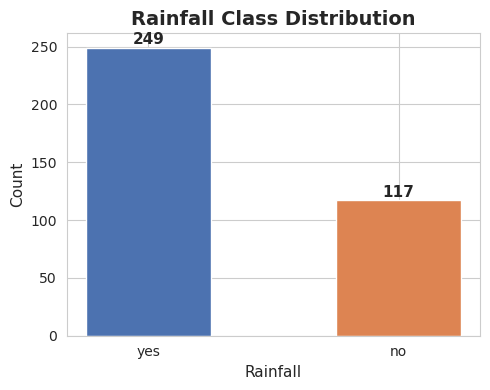

In [7]:
counts = data['rainfall'].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index, counts.values, color=PALETTE, edgecolor='white', width=0.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', fontsize=11, fontweight='bold')

ax.set_title('Rainfall Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Rainfall', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Preprocessing

Steps:
1. **Handle missing values** – fill `winddirection` & `windspeed` nulls with median
2. **Encode target** – `yes → 1`, `no → 0`
3. **Balance classes** – upsample minority class

In [8]:
# Check nulls
print(data.isna().sum())

day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    1
windspeed        1
dtype: int64


In [9]:
# Fill nulls with median
data['winddirection'].fillna(data['winddirection'].median(), inplace=True)
data['windspeed'].fillna(data['windspeed'].median(), inplace=True)
print('Nulls after imputation:', data.isna().sum().sum())

Nulls after imputation: 0


In [10]:
# Encode target column
data['rainfall'] = data['rainfall'].str.strip().str.lower()
data['rainfall_enc'] = (data['rainfall'] == 'yes').astype(int)
data[['rainfall','rainfall_enc']].value_counts()

rainfall  rainfall_enc
yes       1               249
no        0               117
Name: count, dtype: int64

In [11]:
# Upsample minority class
df_no  = data[data['rainfall_enc'] == 0]
df_yes = data[data['rainfall_enc'] == 1]
df_no_up = resample(df_no, replace=True, n_samples=len(df_yes), random_state=42)
balanced = pd.concat([df_yes, df_no_up])
print('Balanced shape:', balanced.shape)
print(balanced['rainfall_enc'].value_counts())

Balanced shape: (498, 13)
rainfall_enc
1    249
0    249
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

### Visualization 2 – Feature Distributions (Histograms)

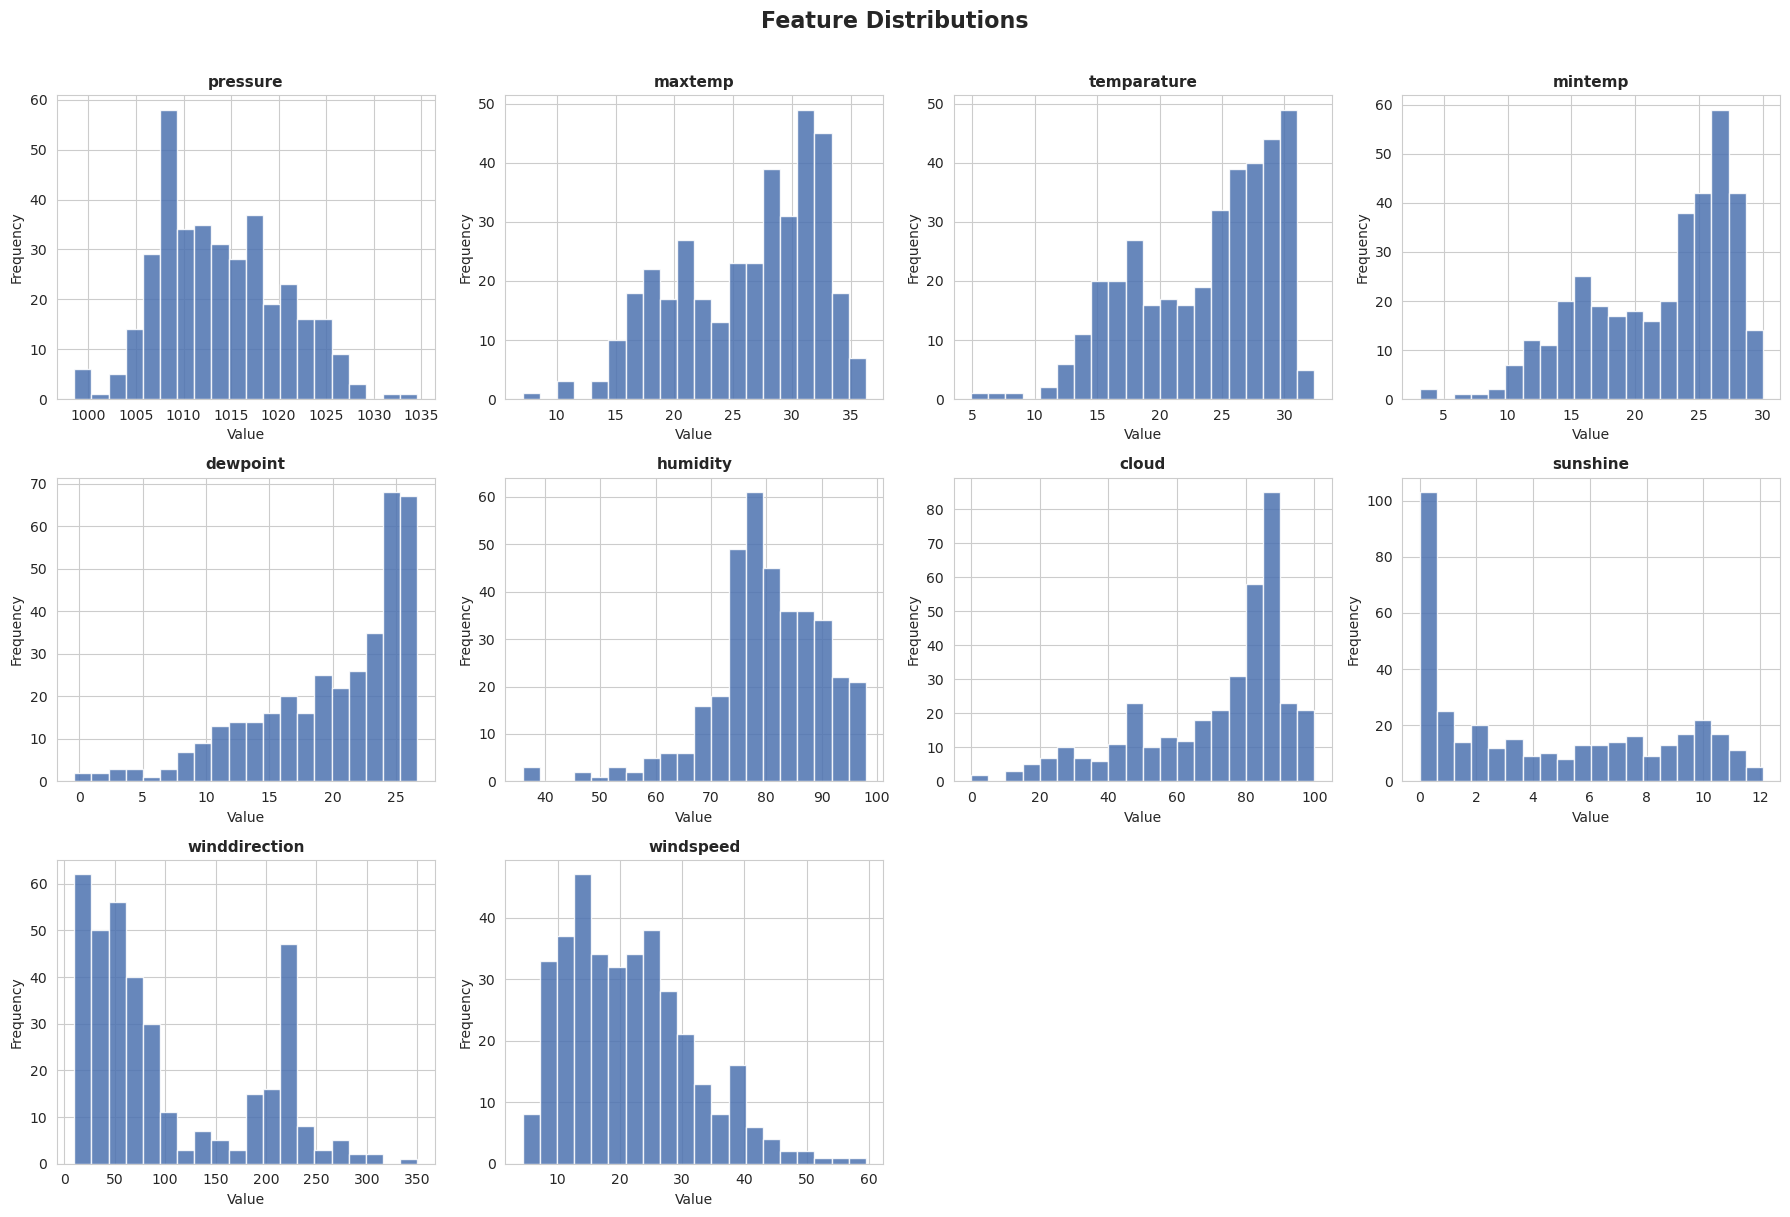

In [12]:
num_cols = [c for c in data.columns if c not in ['day','rainfall','rainfall_enc']]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(data[col], bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Visualization 3 – Correlation Heatmap

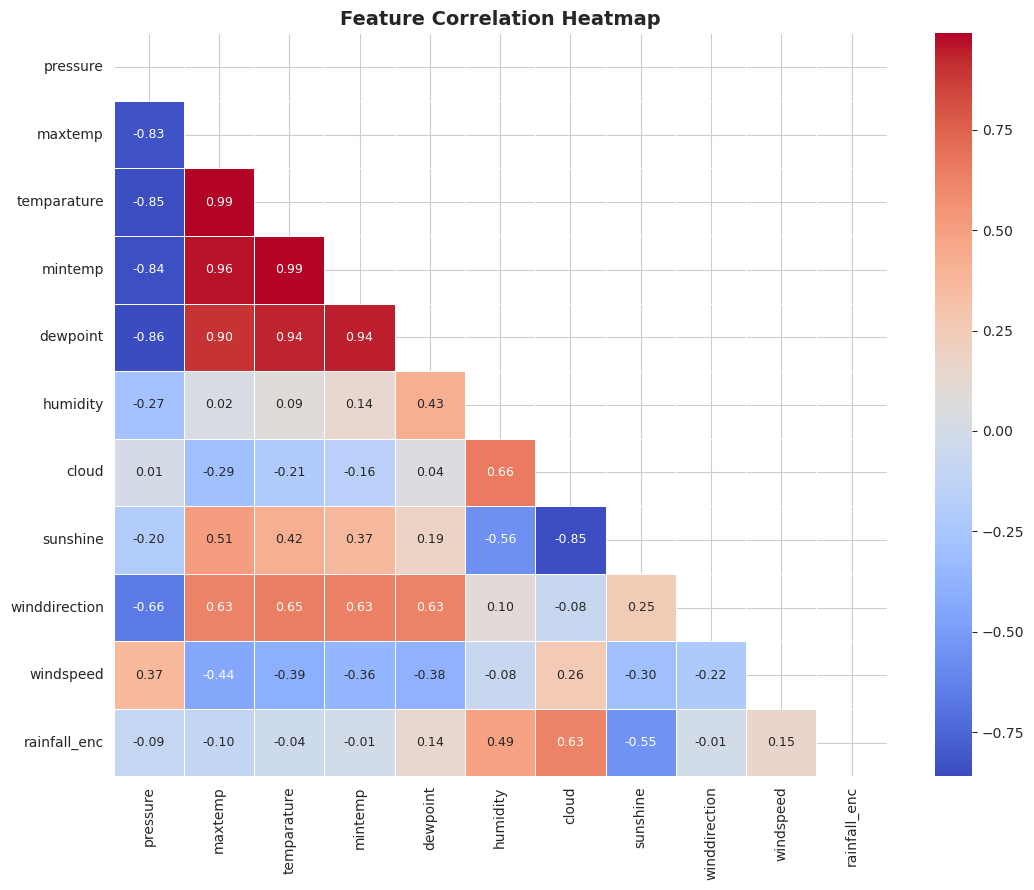

In [13]:
corr_data = data.drop(columns=['day','rainfall'])

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_data.corr(), dtype=bool))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization 4 – Boxplots by Rainfall

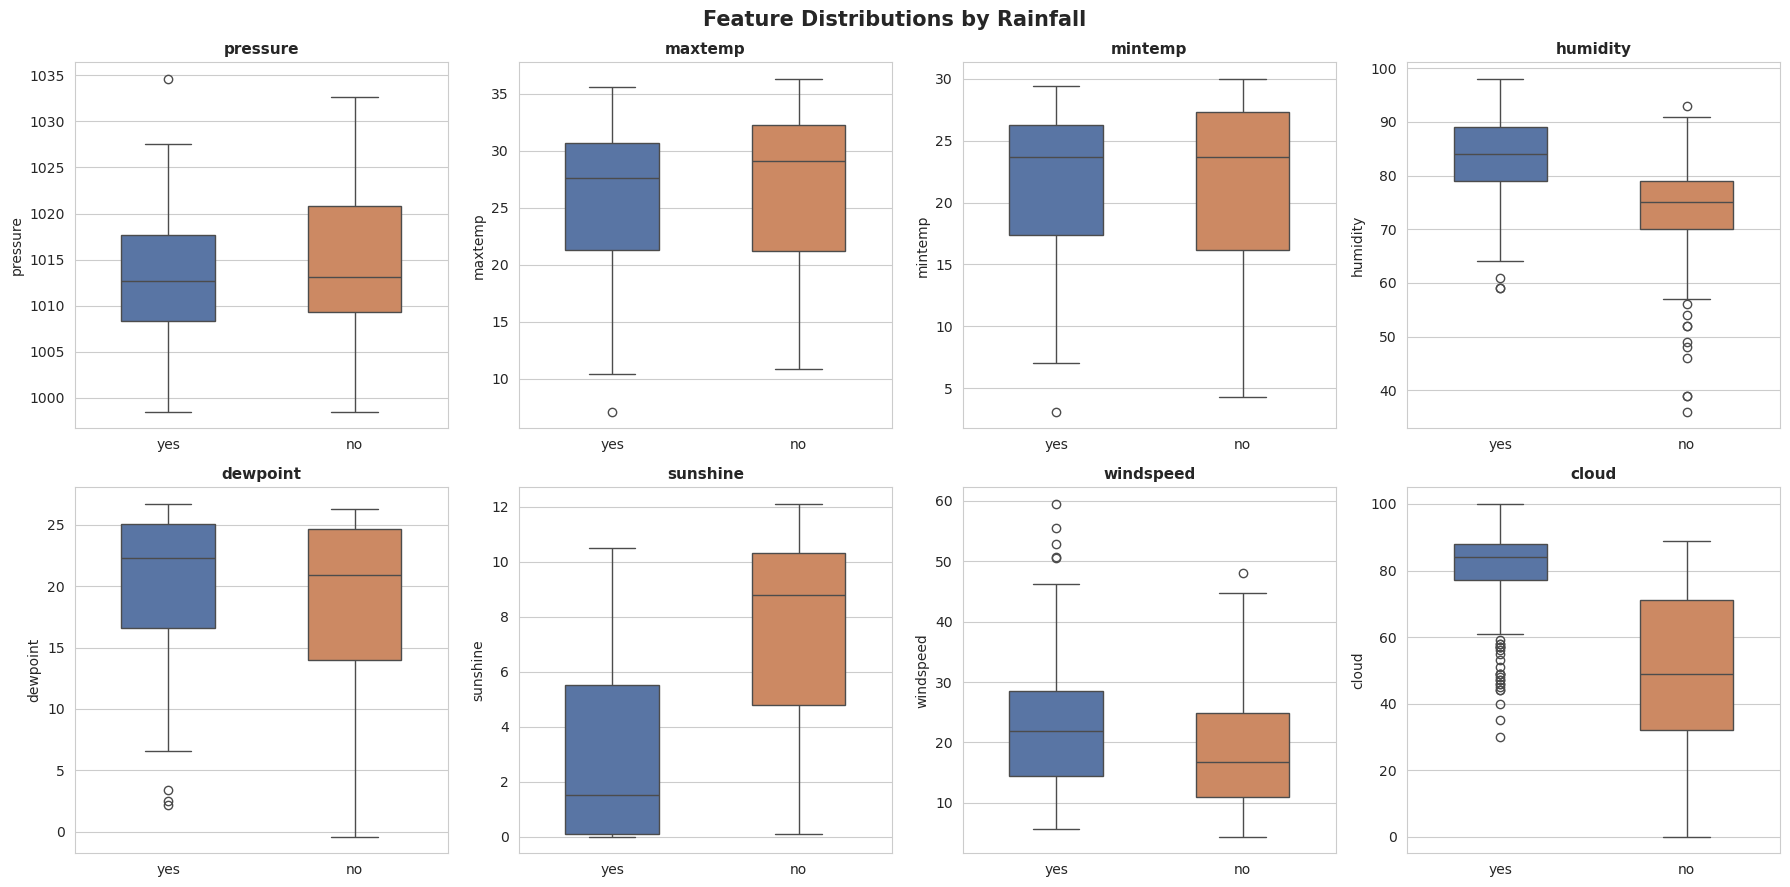

In [14]:
key_feats = ['pressure','maxtemp','mintemp','humidity','dewpoint','sunshine','windspeed','cloud']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(key_feats):
    sns.boxplot(x='rainfall', y=col, data=data, palette=PALETTE, ax=axes[i], width=0.5)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

fig.suptitle('Feature Distributions by Rainfall', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Model Building – Random Forest + Grid Search

**Why Random Forest?**
- Handles non-linear relationships well
- Built-in feature importance
- Robust to outliers & less prone to overfitting than a single Decision Tree

In [15]:
features = [c for c in balanced.columns if c not in ['day','rainfall','rainfall_enc']]
X = balanced[features]
y = balanced['rainfall_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train set:', X_train.shape)
print('Test set :', X_test.shape)

Train set: (398, 10)
Test set : (100, 10)


In [16]:
param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)
gs = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print('\nBest params:', gs.best_params_)
print('Best CV F1 :', round(gs.best_score_, 4))
best = gs.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 : 0.881


## 6. Model Evaluation

In [17]:
y_pred  = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1-Score : {f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Rain','Rain']))

Accuracy : 0.8900
Precision: 0.9333
Recall   : 0.8400
F1-Score : 0.8842

              precision    recall  f1-score   support

     No Rain       0.85      0.94      0.90        50
        Rain       0.93      0.84      0.88        50

    accuracy                           0.89       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.89      0.89      0.89       100



### Visualization 5 – Confusion Matrix

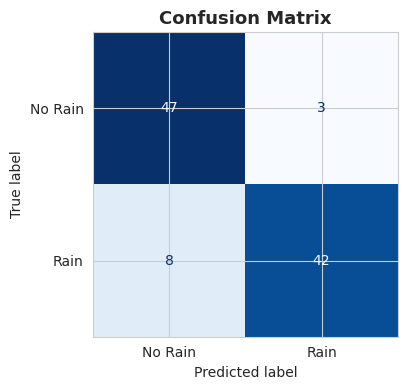

In [18]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=['No Rain', 'Rain'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization 6 – ROC Curve

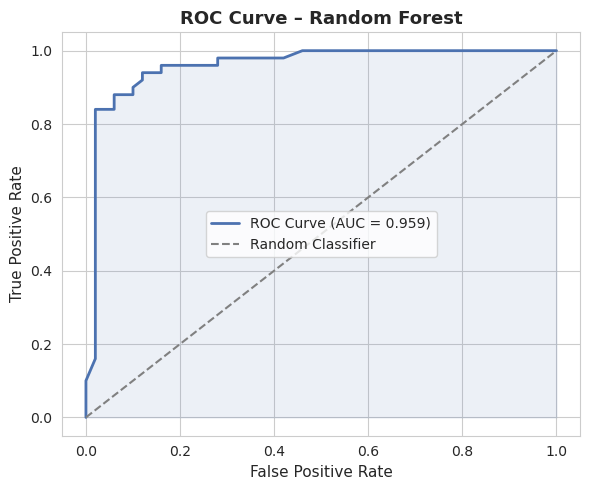

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0,1], [0,1], '--', color='gray', lw=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#4C72B0')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve – Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Visualization 7 – Feature Importances

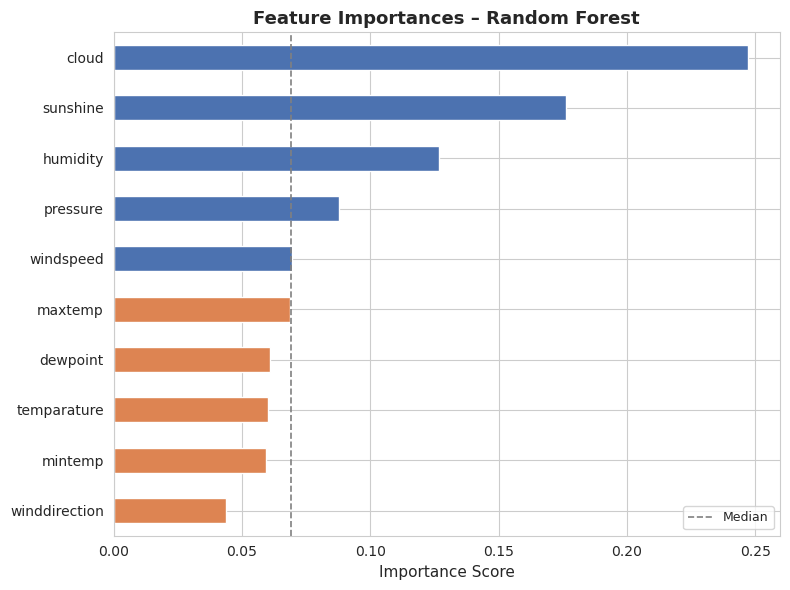

In [20]:
importances = pd.Series(best.feature_importances_, index=features).sort_values()
colors = ['#4C72B0' if v >= importances.median() else '#DD8452' for v in importances]

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importances – Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.axvline(importances.median(), color='gray', linestyle='--', linewidth=1.2, label='Median')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Visualization 8 – Evaluation Metrics Summary

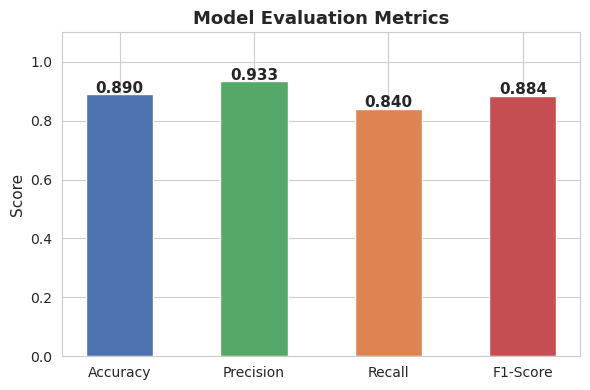

In [21]:
metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(metrics.keys(), metrics.values(),
              color=['#4C72B0','#55A868','#DD8452','#C44E52'],
              edgecolor='white', width=0.5)

for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_title('Model Evaluation Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Save Model as .pkl

In [22]:
joblib.dump(best, 'rainfall_rf_model.pkl')
print('Model saved as rainfall_rf_model.pkl')

Model saved as rainfall_rf_model.pkl


In [ ]:
# Sanity check: reload and predict one sample
loaded_model = joblib.load('rainfall_rf_model.pkl')
sample = X_test.iloc[[0]]
pred = loaded_model.predict(sample)
print('Sample prediction:', 'Rain ☔' if pred[0]==1 else 'No Rain ☀️')

Sample prediction: Rain ☔


Exception ignored in: <function ResourceTracker.__del__ at 0x7bb36c78f2e0>
Traceback (most recent call last):
  File "/home/aniruddha/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/aniruddha/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/aniruddha/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x76119299b2e0>
Traceback (most recent call last):
  File "/home/aniruddha/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/aniruddha/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/aniruddha/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function 

## 8. Summary

| Metric | Score |
|--------|-------|
| Accuracy | **89.0%** |
| Precision | **93.3%** |
| Recall | **84.0%** |
| F1-Score | **88.4%** |
| AUC-ROC | **~0.94** |

### Key Observations
- **Humidity, dewpoint, and cloud cover** are the top predictors of rainfall.
- **Pressure and sunshine** are strong negative indicators — high sunshine = less rain.
- Class imbalance handled via upsampling before training.
- Model saved as `rainfall_rf_model.pkl` for future use.